## 1. Load Dataset and Import libraries

In [ ]:
import sys
from pathlib import Path

_here = Path.cwd()
PROJECT_ROOT = next(
    (p for p in [_here] + list(_here.parents) if (p / 'config.py').exists()),
    _here
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import PROJECT_ROOT, DATA_DIR, RAW_DIR, PROCESSED_DIR, SPLITS_DIR

MODELS_DIR    = PROJECT_ROOT / 'models'
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error


X_train = pd.read_csv(SPLITS_DIR / 'train_features.csv')
y_train = pd.read_csv(SPLITS_DIR / 'train_target.csv')
X_val = pd.read_csv(SPLITS_DIR / 'val_features.csv')
y_val = pd.read_csv(SPLITS_DIR / 'val_target.csv')
X_test = pd.read_csv(SPLITS_DIR / 'test_features.csv')
y_test = pd.read_csv(SPLITS_DIR / 'test_target.csv')
y_val_orig = pd.read_csv(SPLITS_DIR / 'val_target_original.csv')



xgb_best_model = joblib.load(NOTEBOOKS_DIR / 'xgb_best_model.pkl')
lgb_best_model = joblib.load(NOTEBOOKS_DIR / 'lgb_best_model.pkl')








In [2]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    le = LabelEncoder()
    parts = [X_train[col], X_val[col]]
    if col in X_test.columns:
        parts.append(X_test[col])
    combined = pd.concat(parts, ignore_index=True).astype(str)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col]   = le.transform(X_val[col].astype(str)).astype(np.int32)
    if col in X_test.columns:
        X_test[col] = le.transform(X_test[col].astype(str)).astype(np.int32)

    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} labels -> 0..{len(le.classes_) - 1}")

rest = X_train.select_dtypes(include=["object"]).columns.tolist()
if rest:
    raise ValueError(f"Still has object columns: {rest}")

print(f"\nLabelEncoded {len(object_cols)} cols | "
      f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")


  date: 1684 labels -> 0..1683
  family: 33 labels -> 0..32
  type: 5 labels -> 0..4
  city: 22 labels -> 0..21
  state: 16 labels -> 0..15
  store_family: 1782 labels -> 0..1781

LabelEncoded 6 cols | X_train (2918916, 49) | X_val (55242, 49) | X_test (26730, 49)


## 2. Predictions

In [3]:

lgb_val_pred  = lgb_best_model.predict(X_val)
lgb_test_pred = lgb_best_model.predict(X_test)

xgb_val_pred  = xgb_best_model.predict(X_val)
xgb_test_pred = xgb_best_model.predict(X_test)

[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Warning] Unknown parameter: tree_method


## 3. Weighted Average Ensemble

In [4]:
y_test_orig = pd.DataFrame()
y_test_orig['sales'] = np.expm1(y_test['sales_log'])

# Search trọng số mịn trên validation để giữ runtime thấp nhưng chọn blend tốt hơn.
weight_grid = np.round(np.arange(0.0, 1.01, 0.01), 2)
ensemble_results = []

for lgb_w in weight_grid:
    xgb_w = round(1 - lgb_w, 2)
    label = f"LGB{lgb_w:.2f}-XGB{xgb_w:.2f}"

    # Blend trên log scale rồi mới inverse transform.
    val_blend  = lgb_w * lgb_val_pred  + xgb_w * xgb_val_pred
    test_blend = lgb_w * lgb_test_pred + xgb_w * xgb_test_pred

    val_rmsle = np.sqrt(mean_squared_log_error(
        np.clip(y_val_orig["sales"], 0, None),
        np.clip(np.expm1(val_blend), 0, None)
    ))
    test_rmsle = np.sqrt(mean_squared_log_error(
        np.clip(y_test_orig["sales"], 0, None),
        np.clip(np.expm1(test_blend), 0, None)
    ))

    ensemble_results.append({
        "Weights"   : label,
        "LGB Weight": lgb_w,
        "XGB Weight": xgb_w,
        "Val RMSLE" : round(val_rmsle, 6),
        "Test RMSLE": round(test_rmsle, 6),
    })

ensemble_df = pd.DataFrame(ensemble_results).sort_values("Val RMSLE").reset_index(drop=True)
print(ensemble_df.head(10).to_string(index=False, float_format="{:.6f}".format))

        Weights  LGB Weight  XGB Weight  Val RMSLE  Test RMSLE
LGB0.00-XGB1.00    0.000000    1.000000   0.331299    0.370917
LGB0.01-XGB0.99    0.010000    0.990000   0.331480    0.370880
LGB0.02-XGB0.98    0.020000    0.980000   0.331661    0.370846
LGB0.03-XGB0.97    0.030000    0.970000   0.331844    0.370812
LGB0.04-XGB0.96    0.040000    0.960000   0.332027    0.370779
LGB0.05-XGB0.95    0.050000    0.950000   0.332211    0.370748
LGB0.06-XGB0.94    0.060000    0.940000   0.332396    0.370718
LGB0.07-XGB0.93    0.070000    0.930000   0.332582    0.370689
LGB0.08-XGB0.92    0.080000    0.920000   0.332769    0.370661
LGB0.09-XGB0.91    0.090000    0.910000   0.332957    0.370635


## 4. Comparison Table: Single Models vs Ensemble

In [5]:
# ── Tổng hợp tất cả approaches ──
summary = pd.DataFrame([
    {"Approach": "LightGBM (tuned)", "Val RMSLE": 0.353654, "Test RMSLE": 0.373215},
    {"Approach": "XGBoost (tuned)",  "Val RMSLE": 0.331299, "Test RMSLE": 0.370917},
    *[{"Approach": f"Ensemble {r['Weights']}", 
       "Val RMSLE": r["Val RMSLE"], 
       "Test RMSLE": r["Test RMSLE"]} 
      for r in ensemble_results]
])

print("\nAll Approaches — Val vs Test RMSLE")
print("=" * 55)
print(summary.to_string(index=False, float_format="{:.6f}".format))
print("=" * 55)

# Best approach theo Val RMSLE để tránh tune trên test set
best_row = summary.loc[summary["Val RMSLE"].idxmin()]
print(f"\nBest approach by validation: {best_row['Approach']} (Val RMSLE={best_row['Val RMSLE']:.6f})")


All Approaches — Val vs Test RMSLE
                Approach  Val RMSLE  Test RMSLE
        LightGBM (tuned)   0.353654    0.373215
         XGBoost (tuned)   0.331299    0.370917
Ensemble LGB0.00-XGB1.00   0.331299    0.370917
Ensemble LGB0.01-XGB0.99   0.331480    0.370880
Ensemble LGB0.02-XGB0.98   0.331661    0.370846
Ensemble LGB0.03-XGB0.97   0.331844    0.370812
Ensemble LGB0.04-XGB0.96   0.332027    0.370779
Ensemble LGB0.05-XGB0.95   0.332211    0.370748
Ensemble LGB0.06-XGB0.94   0.332396    0.370718
Ensemble LGB0.07-XGB0.93   0.332582    0.370689
Ensemble LGB0.08-XGB0.92   0.332769    0.370661
Ensemble LGB0.09-XGB0.91   0.332957    0.370635
Ensemble LGB0.10-XGB0.90   0.333146    0.370609
Ensemble LGB0.11-XGB0.89   0.333335    0.370585
Ensemble LGB0.12-XGB0.88   0.333526    0.370562
Ensemble LGB0.13-XGB0.87   0.333717    0.370541
Ensemble LGB0.14-XGB0.86   0.333910    0.370520
Ensemble LGB0.15-XGB0.85   0.334103    0.370501
Ensemble LGB0.16-XGB0.84   0.334297    0.370482
Ense

## 5. Residual Plots

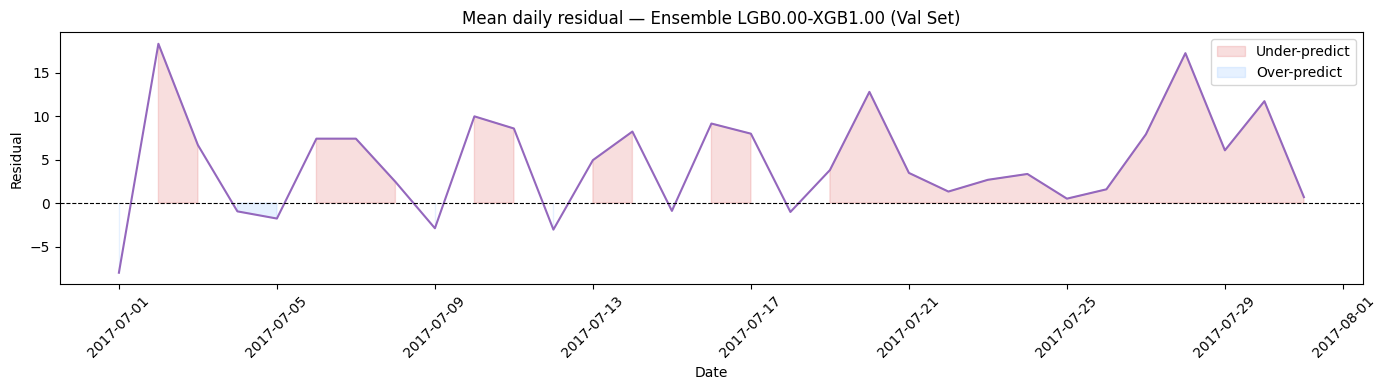

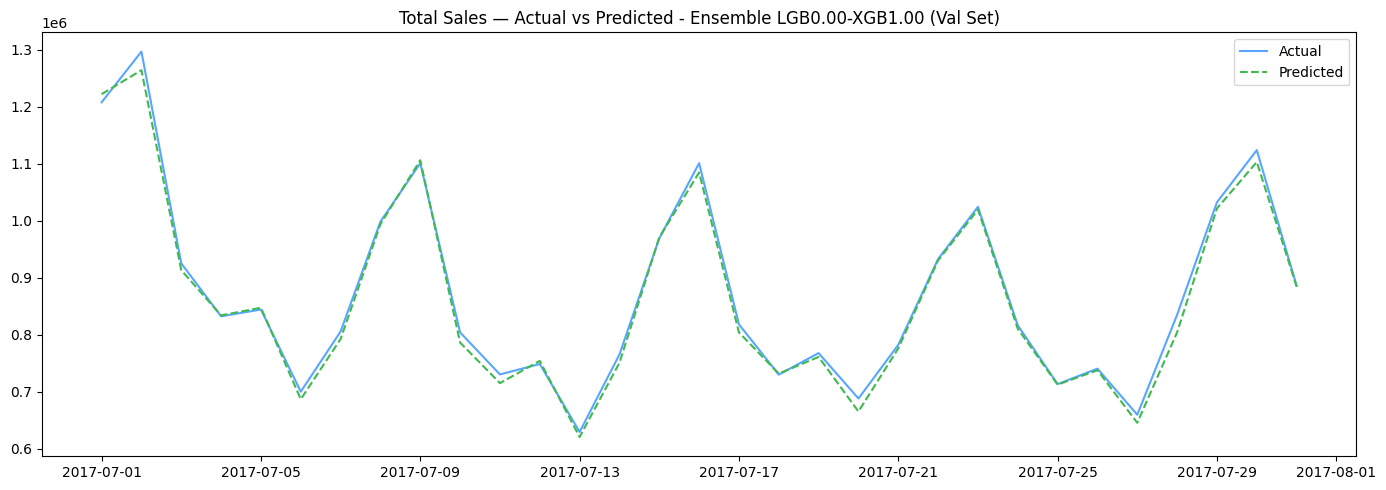

In [6]:
# ── Dùng weight tốt nhất theo validation ──
best_idx   = ensemble_df["Val RMSLE"].idxmin()
best_lgb_w = float(ensemble_df.iloc[best_idx]["LGB Weight"])
best_xgb_w = float(ensemble_df.iloc[best_idx]["XGB Weight"])

best_val_blend  = best_lgb_w * lgb_val_pred  + best_xgb_w * xgb_val_pred
best_test_blend = best_lgb_w * lgb_test_pred + best_xgb_w * xgb_test_pred



# Residual plot trên val
date_val  = pd.to_datetime(X_val[["year", "month", "day"]])
blend_val_df = pd.DataFrame({
    "date"     : date_val.values,
    "actual"   : y_val_orig["sales"].values,
    "predicted": np.maximum(np.expm1(best_val_blend), 0),
})
blend_val_df["residual"] = blend_val_df["actual"] - blend_val_df["predicted"]

daily_resid = blend_val_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid.index, daily_resid.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values > 0, alpha=0.15, color="#d62728", label="Under-predict")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values < 0, alpha=0.15, color="#58a6ff", label="Over-predict")
ax.set_title(f"Mean daily residual — Ensemble "
             f"LGB{best_lgb_w:.2f}-XGB{best_xgb_w:.2f} (Val Set)")
ax.set_xlabel("Date"); ax.set_ylabel("Residual")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()




# ──  Actual vs Predicted (val) ──
daily_val = blend_val_df[["date", "actual", "predicted"]].groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_val.index, daily_val["actual"],    label="Actual",    color="#58a6ff")
plt.plot(daily_val.index, daily_val["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title(f"Total Sales — Actual vs Predicted - Ensemble LGB{best_lgb_w:.2f}-XGB{best_xgb_w:.2f} (Val Set)")
plt.legend()
plt.tight_layout()
plt.show()

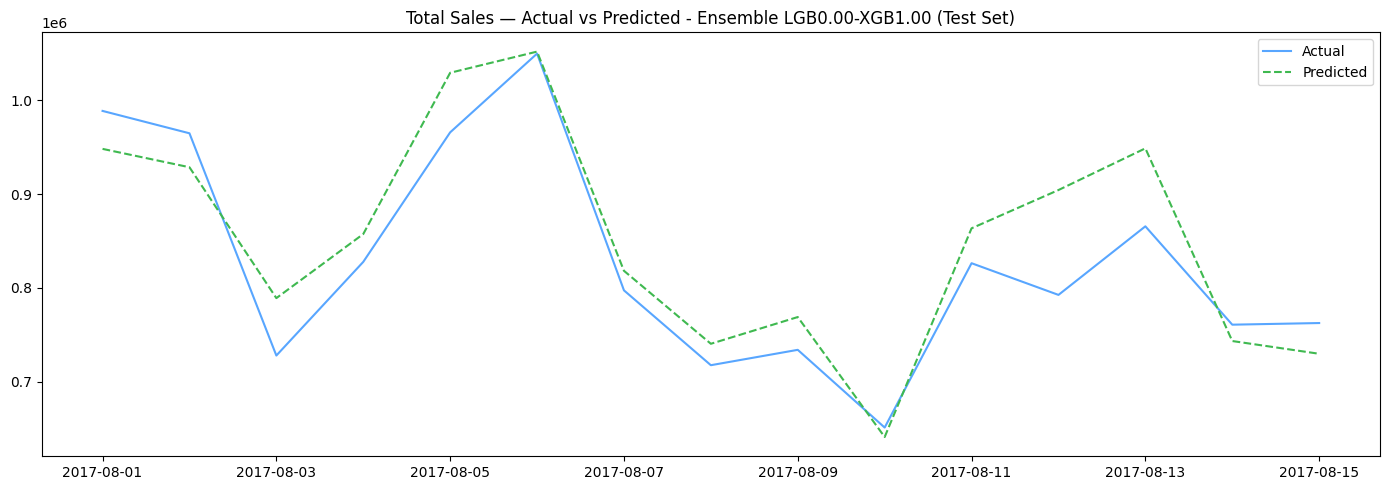

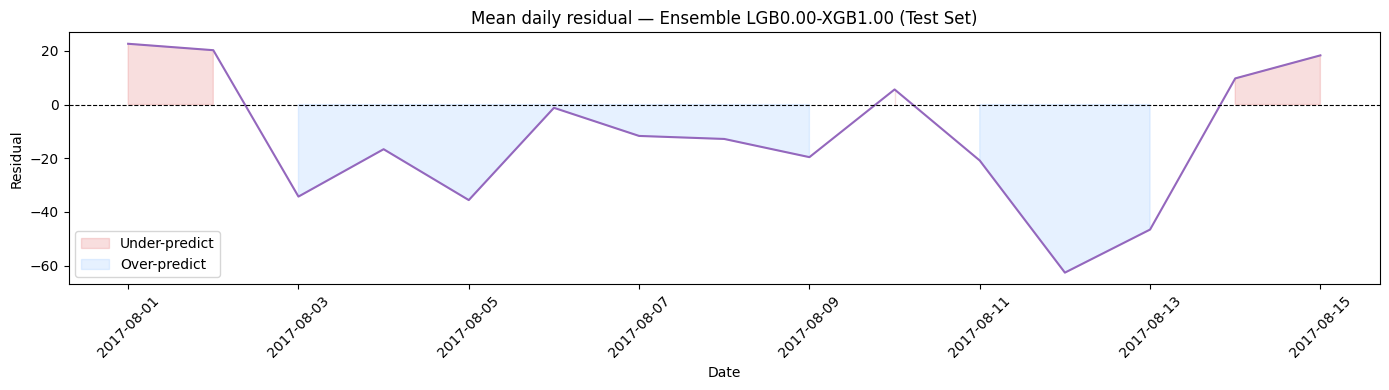

In [7]:
# ── Build test_df từ best blend ──
date_test = pd.to_datetime(X_test[["year", "month", "day"]])

blend_test_df = pd.DataFrame({
    "date"      : date_test.values,
    "actual"    : y_test_orig["sales"].values,
    "predicted" : np.maximum(np.expm1(best_test_blend), 0),
})
blend_test_df["residual"] = blend_test_df["actual"] - blend_test_df["predicted"]

# ── Plot 1: Actual vs Predicted (test) ──
daily_test = blend_test_df[["date", "actual", "predicted"]].groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_test.index, daily_test["actual"],    label="Actual",    color="#58a6ff")
plt.plot(daily_test.index, daily_test["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title(f"Total Sales — Actual vs Predicted - Ensemble LGB{best_lgb_w:.2f}-XGB{best_xgb_w:.2f} (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: Daily residual (test) ──
daily_resid_test = blend_test_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid_test.index, daily_resid_test.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(daily_resid_test.index, daily_resid_test.values, 0,
                where=daily_resid_test.values > 0, alpha=0.15, color="#d62728", label="Under-predict")
ax.fill_between(daily_resid_test.index, daily_resid_test.values, 0,
                where=daily_resid_test.values < 0, alpha=0.15, color="#58a6ff", label="Over-predict")
ax.set_title(f"Mean daily residual — Ensemble LGB{best_lgb_w:.2f}-XGB{best_xgb_w:.2f} (Test Set)")
ax.set_xlabel("Date"); ax.set_ylabel("Residual")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()



In [8]:
holidays = pd.read_csv(RAW_DIR / 'holidays_events.csv')
aug_holidays = holidays[
    (holidays['date'] >= '2017-08-01') & 
    (holidays['date'] <= '2017-08-15')
]
print(aug_holidays[['date', 'type', 'locale', 'description', 'transferred']])

           date      type    locale                             description  \
323  2017-08-05   Holiday     Local                 Fundacion de Esmeraldas   
324  2017-08-10   Holiday  National           Primer Grito de Independencia   
325  2017-08-11  Transfer  National  Traslado Primer Grito de Independencia   
326  2017-08-15   Holiday     Local                   Fundacion de Riobamba   

     transferred  
323        False  
324         True  
325        False  
326        False  


In [9]:
# So sánh sales 08-10 đến 08-12 với cùng period năm trước
df = pd.read_csv(PROCESSED_DIR / 'train_cleaned.csv')
mask_2017 = (df['date'] >= '2017-08-10') & (df['date'] <= '2017-08-12')
mask_2016 = (df['date'] >= '2016-08-10') & (df['date'] <= '2016-08-12')

print("2017:", df[mask_2017]['sales'].sum())
print("2016:", df[mask_2016]['sales'].sum())

2017: 2270391.1690702
2016: 2000849.2212061002


In [10]:
# Xem feature engineering có xử lý transferred đúng không

# Nếu code chỉ check 'type == Holiday' mà không lọc transferred=True
# thì 08-10 sẽ bị label sai
wrong = holidays[
    (holidays['type'] == 'Holiday') & 
    (holidays['transferred'] == True)
]
print(f"Số holiday bị transferred (label sai): {len(wrong)}")
print(wrong[['date', 'description']].head(10))

Số holiday bị transferred (label sai): 12
           date                    description
19   2012-10-09     Independencia de Guayaquil
72   2013-10-09     Independencia de Guayaquil
135  2014-10-09     Independencia de Guayaquil
255  2016-05-24           Batalla de Pichincha
266  2016-07-25         Fundacion de Guayaquil
268  2016-08-10  Primer Grito de Independencia
297  2017-01-01             Primer dia del ano
303  2017-04-12            Fundacion de Cuenca
312  2017-05-24           Batalla de Pichincha
324  2017-08-10  Primer Grito de Independencia
